# Fully Connected PyTorch Visualizer Demo

This notebook turns a small PyTorch dense network into a lecture-style diagram like the hand-drawn sketch.

New capability:

- for **small** fully connected networks, the visualizer can annotate edge weights, node biases, and forward-pass values
- if you pass an `input_vector`, it computes `z` and `a` layer by layer

It works for:

- `nn.Sequential(...)` models made of `nn.Linear` + common activations
- custom `nn.Module` classes that still form a feed-forward fully connected network

It is intentionally **not** for CNNs, residual blocks, attention, or branching graphs.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(7)

repo_root = Path.cwd().resolve()
if repo_root.name == "lecture_demo":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from fc_model_visualizer import (
    extract_fully_connected_architecture,
    save_figure,
    visualize_fully_connected_model,
)

plt.rcParams["figure.figsize"] = (12, 6)
print(f"Repo root: {repo_root}")
print(f"Torch version: {torch.__version__}")
%config InlineBackend.figure_format = "retina"


Repo root: /Users/nipun/git/principles-ai-teaching
Torch version: 2.9.1


## 1. Small Network With Full Annotation

This is the best teaching case because we can see everything:

- `W` on the edges
- `b` near each neuron
- `z = W a + b`
- `a = g(z)`
- the actual matrix values in a side panel

Design cue:

- incoming edges that feed the same neuron share a color
- the `z`, `a`, and `b` badges for that neuron use the same accent color


In [2]:
small_model = nn.Sequential(
    nn.Linear(2, 2),
    nn.ReLU(),
    nn.Linear(2, 1),
    nn.Sigmoid(),
)

with torch.no_grad():
    small_model[0].weight.copy_(torch.tensor([[1.0, -0.5], [0.3, 0.8]]))
    small_model[0].bias.copy_(torch.tensor([0.2, -0.1]))
    small_model[2].weight.copy_(torch.tensor([[0.7, -1.2]]))
    small_model[2].bias.copy_(torch.tensor([0.05]))

x_example = torch.tensor([0.6, -0.4], dtype=torch.float32)

print(small_model)
print()
print("Architecture:")
print(extract_fully_connected_architecture(small_model))
print()
print("Input example:", x_example)
print("W[1] =")
print(small_model[0].weight.detach())
print("b[1] =", small_model[0].bias.detach())
print("W[2] =")
print(small_model[2].weight.detach())
print("b[2] =", small_model[2].bias.detach())


Sequential(
  (0): Linear(in_features=2, out_features=2, bias=True)
  (1): ReLU()
  (2): Linear(in_features=2, out_features=1, bias=True)
  (3): Sigmoid()
)

Architecture:
[LinearLayerSpec(in_features=2, out_features=2, activation='ReLU', name='0'), LinearLayerSpec(in_features=2, out_features=1, activation='Sigmoid', name='2')]

Input example: tensor([ 0.6000, -0.4000])
W[1] =
tensor([[ 1.0000, -0.5000],
        [ 0.3000,  0.8000]])
b[1] = tensor([ 0.2000, -0.1000])
W[2] =
tensor([[ 0.7000, -1.2000]])
b[2] = tensor([0.0500])


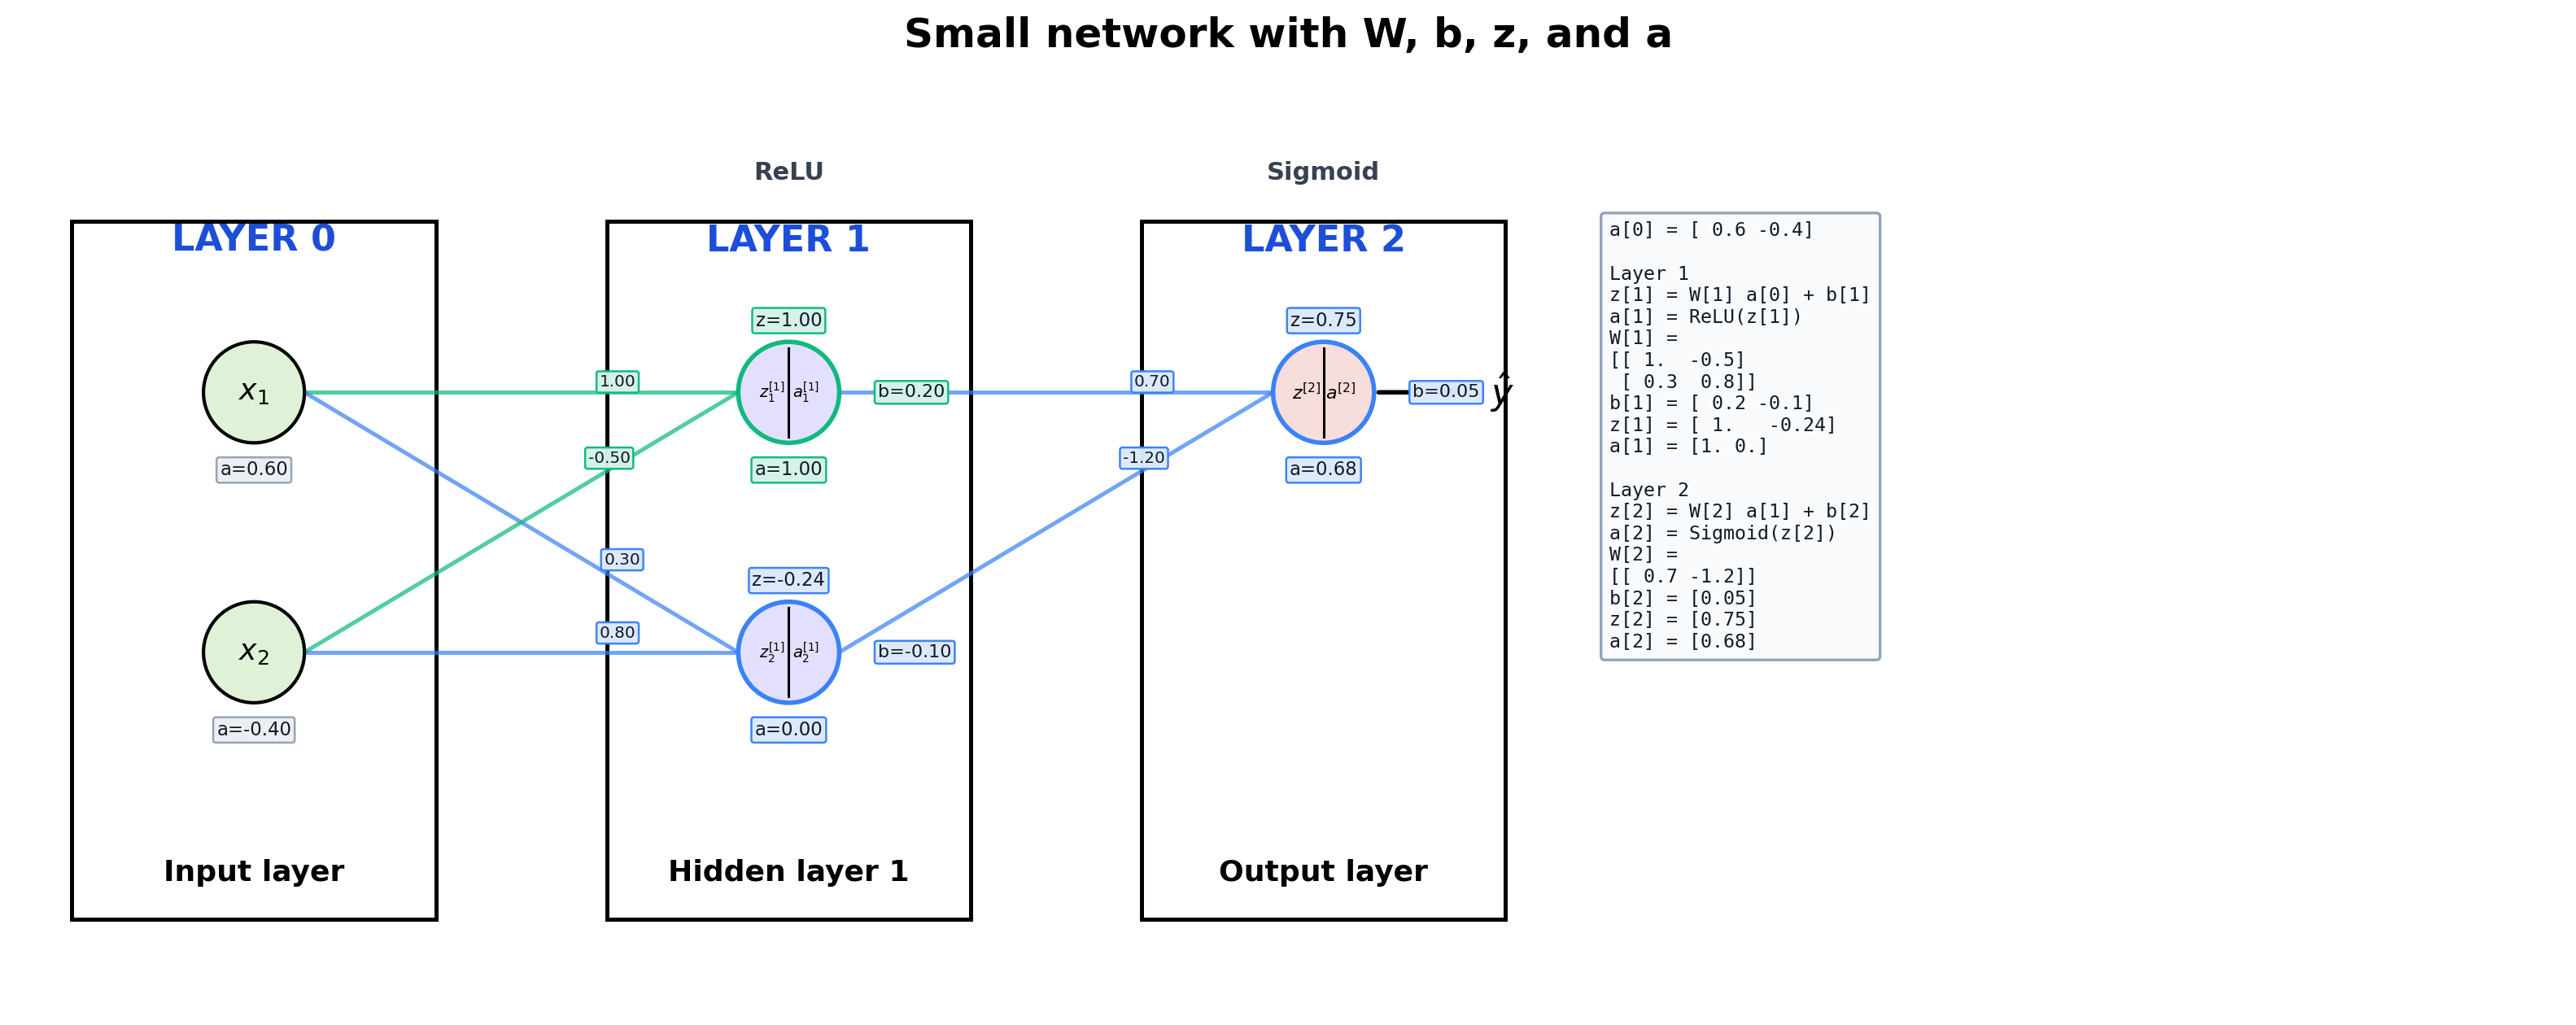

In [3]:
fig, ax = visualize_fully_connected_model(
    small_model,
    input_labels=[r"$x_1$", r"$x_2$"],
    input_vector=x_example,
    title="Small network with W, b, z, and a",
    max_neurons_per_layer=5,
    show_edge_weights=True,
    show_biases=True,
    show_values=True,
    show_matrix_details=True,
)
plt.show()


## 2. A More Typical Sequential Model

The same API works for ordinary lecture examples. It just stops annotating every scalar once the plot would become cluttered.


In [4]:
sequential_model = nn.Sequential(
    nn.Linear(4, 3),
    nn.ReLU(),
    nn.Linear(3, 2),
    nn.Tanh(),
    nn.Linear(2, 1),
    nn.Sigmoid(),
)

print(sequential_model)
print()
print(extract_fully_connected_architecture(sequential_model))


Sequential(
  (0): Linear(in_features=4, out_features=3, bias=True)
  (1): ReLU()
  (2): Linear(in_features=3, out_features=2, bias=True)
  (3): Tanh()
  (4): Linear(in_features=2, out_features=1, bias=True)
  (5): Sigmoid()
)

[LinearLayerSpec(in_features=4, out_features=3, activation='ReLU', name='0'), LinearLayerSpec(in_features=3, out_features=2, activation='Tanh', name='2'), LinearLayerSpec(in_features=2, out_features=1, activation='Sigmoid', name='4')]


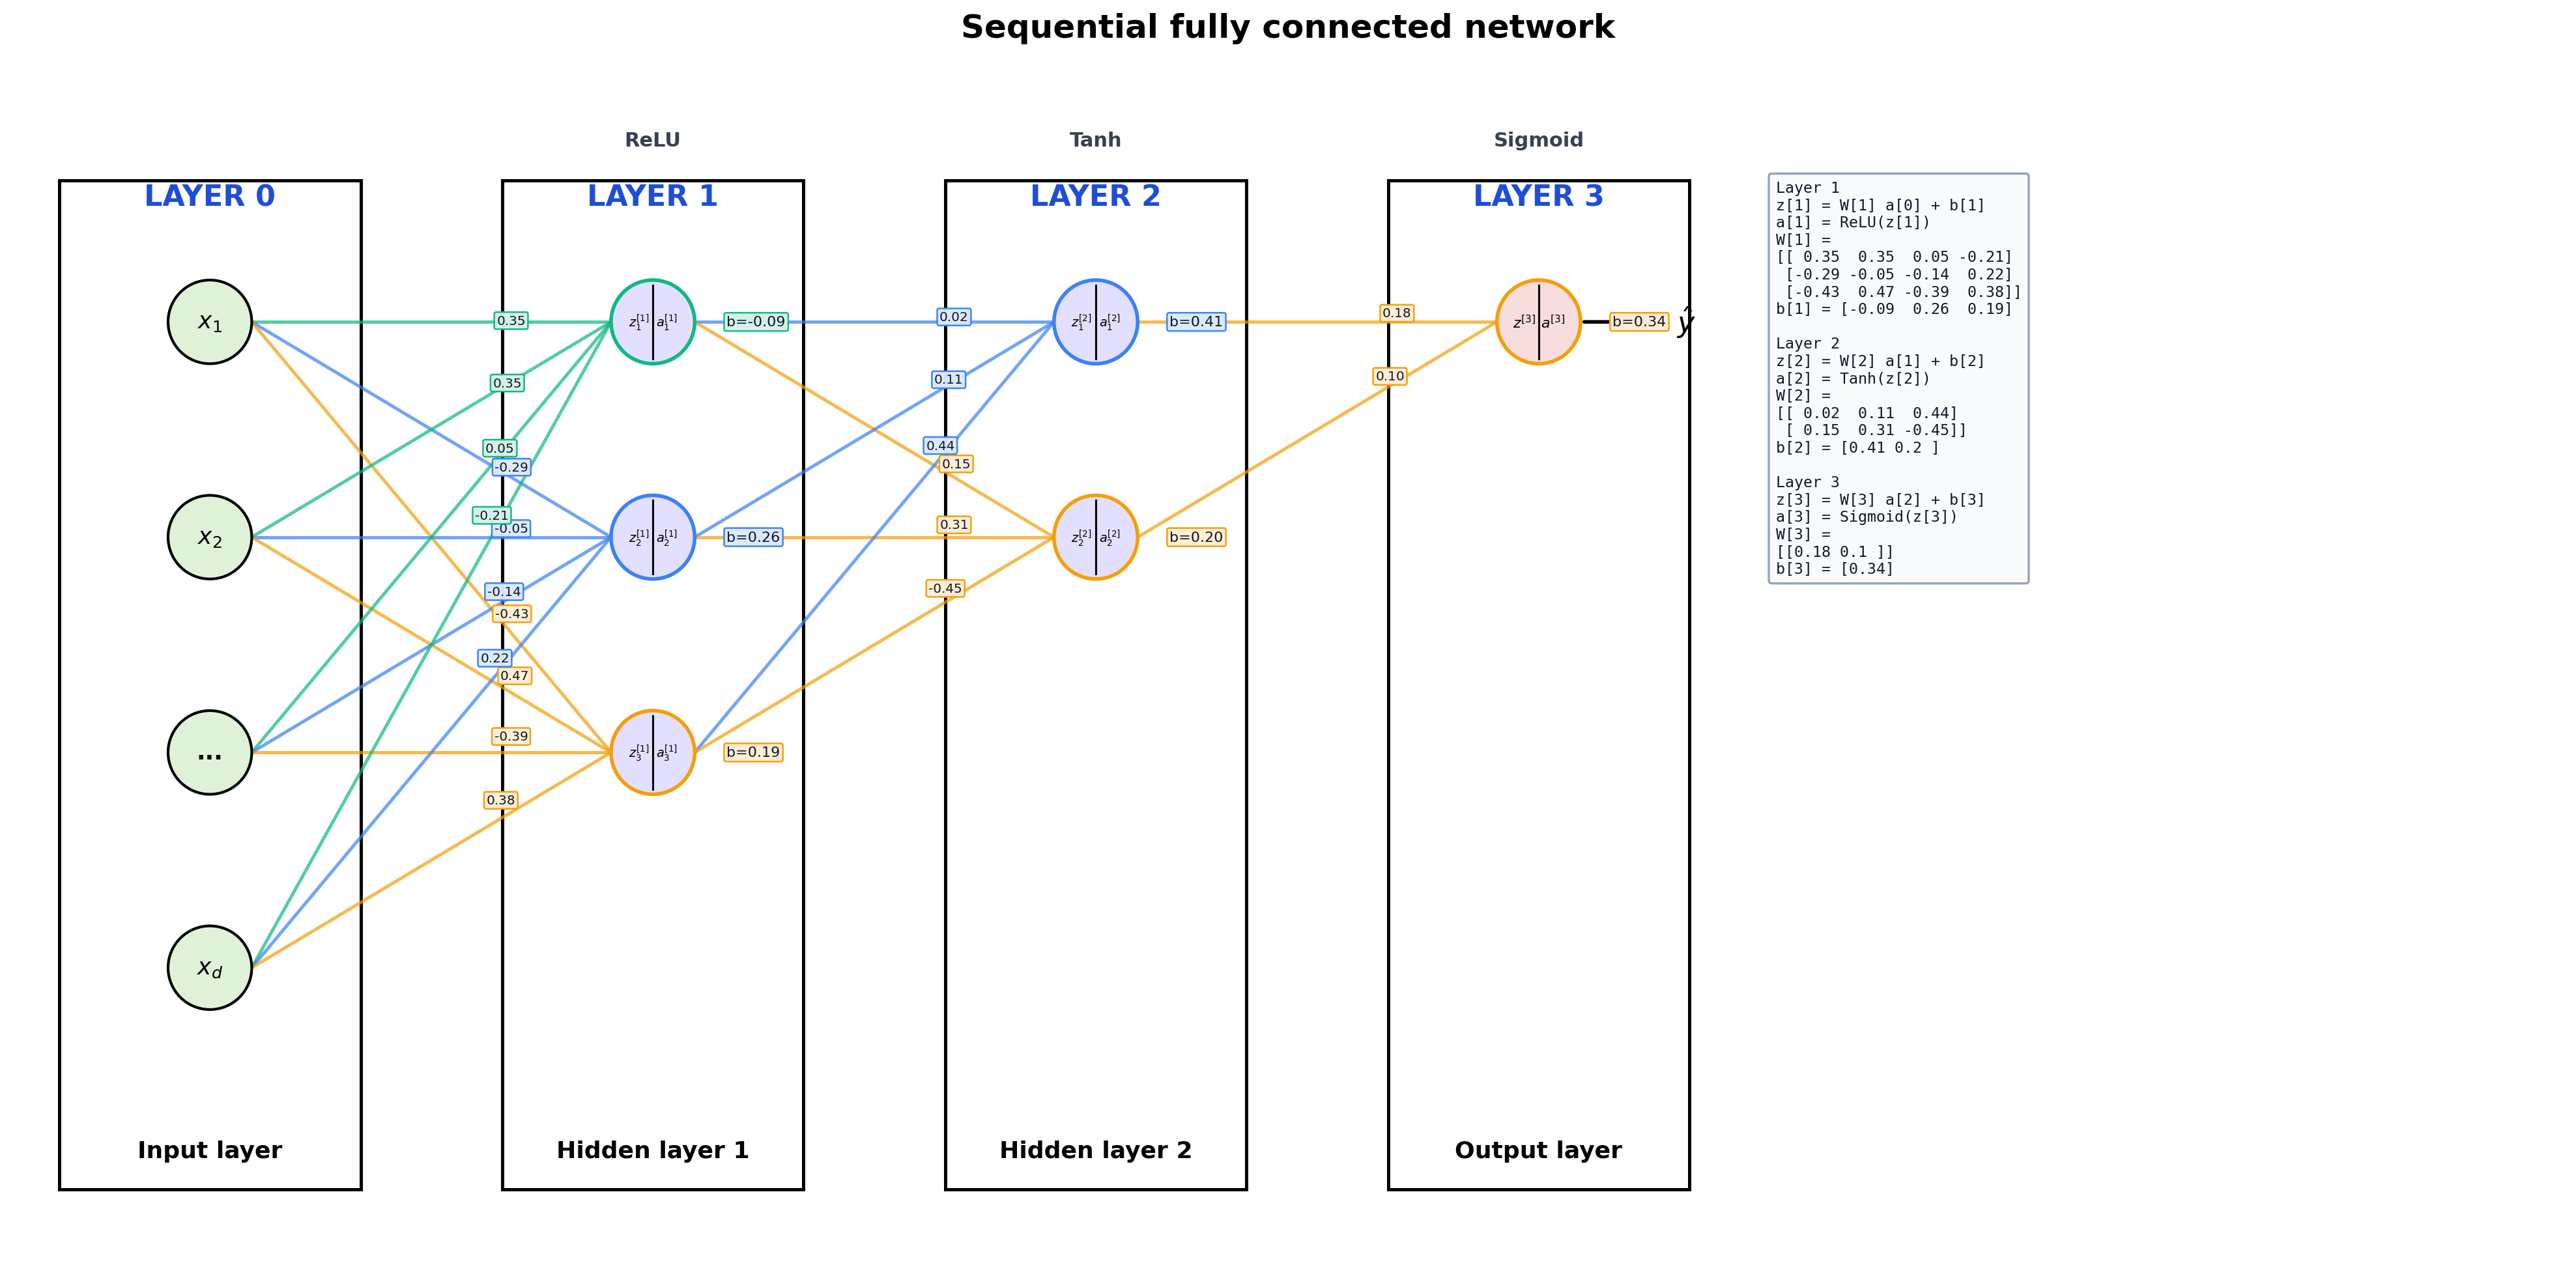

In [5]:
fig, ax = visualize_fully_connected_model(
    sequential_model,
    input_labels=[r"$x_1$", r"$x_2$", "...", r"$x_d$"],
    title="Sequential fully connected network",
    max_neurons_per_layer=5,
)
plt.show()


## 3. Custom `nn.Module`

The visualizer also works when the network is written as a class with named layers.


In [6]:
class SmallClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden1 = nn.Linear(2, 8)
        self.hidden2 = nn.Linear(8, 4)
        self.output = nn.Linear(4, 2)

    def forward(self, x):
        x = torch.relu(self.hidden1(x))
        x = torch.tanh(self.hidden2(x))
        return torch.softmax(self.output(x), dim=-1)


custom_model = SmallClassifier()
print(custom_model)
print()
print(extract_fully_connected_architecture(custom_model))


SmallClassifier(
  (hidden1): Linear(in_features=2, out_features=8, bias=True)
  (hidden2): Linear(in_features=8, out_features=4, bias=True)
  (output): Linear(in_features=4, out_features=2, bias=True)
)

[LinearLayerSpec(in_features=2, out_features=8, activation='ReLU', name='hidden1'), LinearLayerSpec(in_features=8, out_features=4, activation='Tanh', name='hidden2'), LinearLayerSpec(in_features=4, out_features=2, activation='Softmax', name='output')]


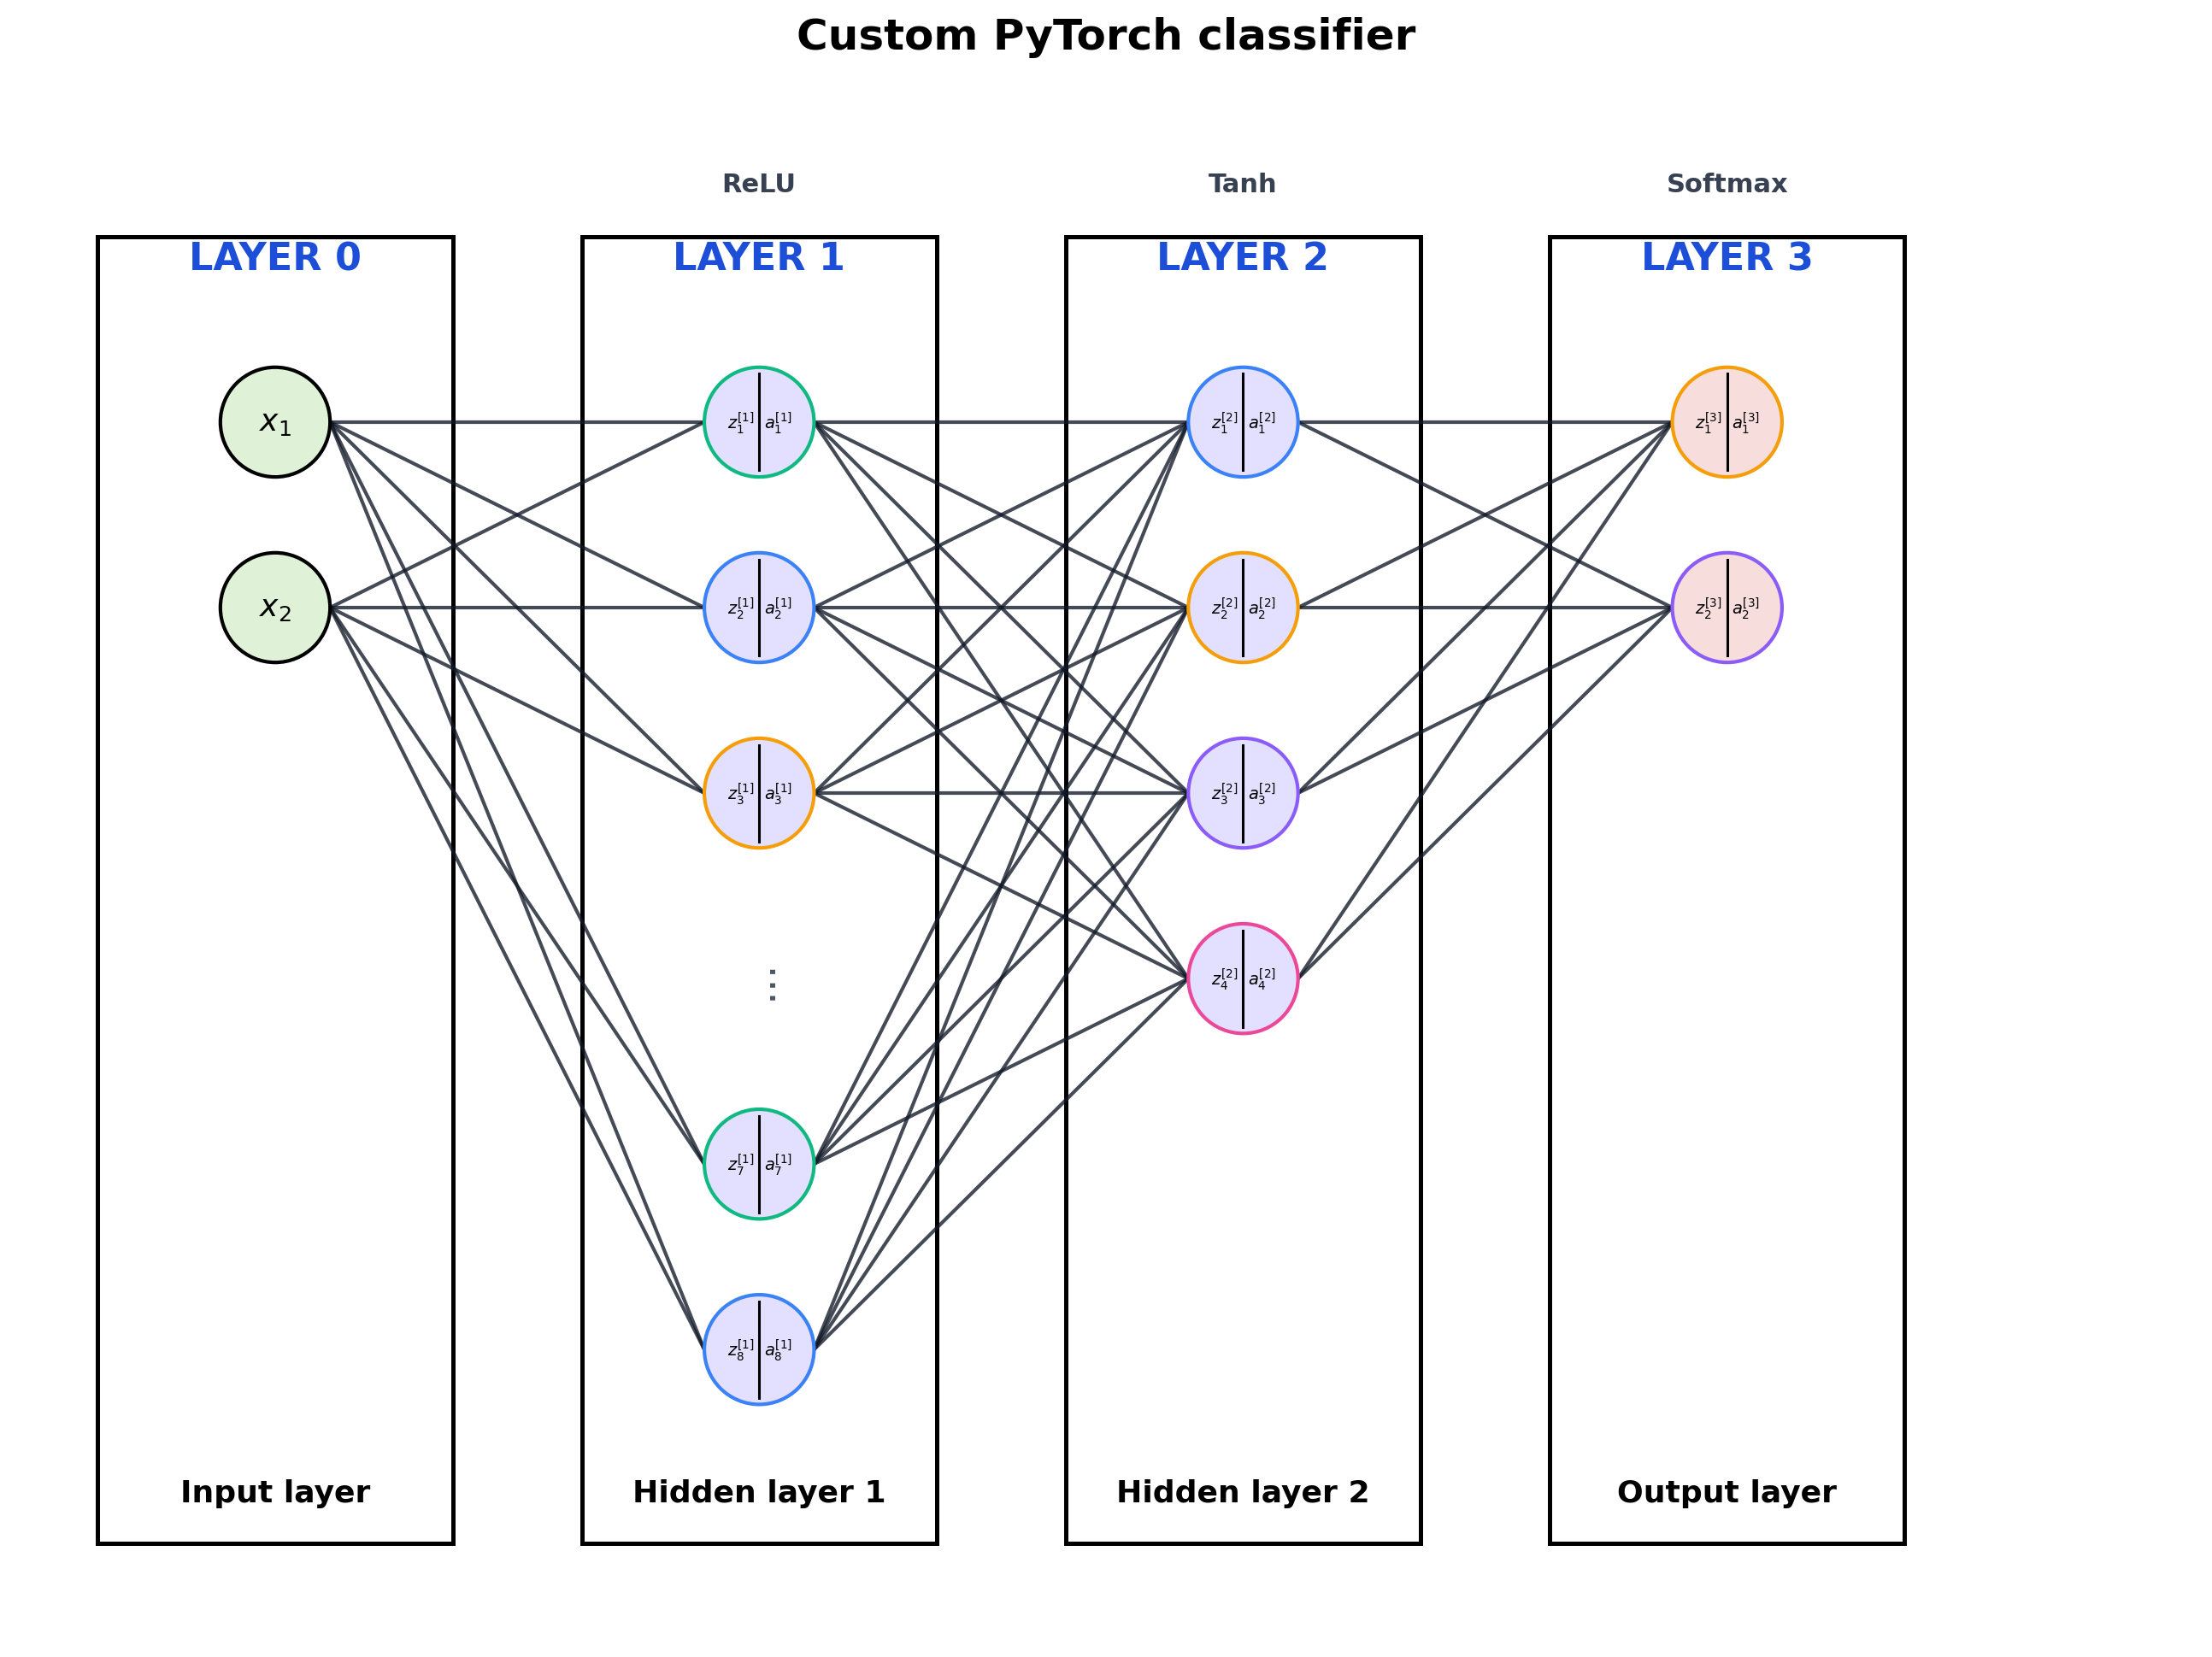

In [7]:
fig, ax = visualize_fully_connected_model(
    custom_model,
    input_labels=[r"$x_1$", r"$x_2$"],
    output_labels=["class 1", "class 2"],
    title="Custom PyTorch classifier",
    max_neurons_per_layer=6,
)
plt.show()


## 4. Wide Model with Truncation

Large dense layers get summarized with `...` so the diagram stays readable.


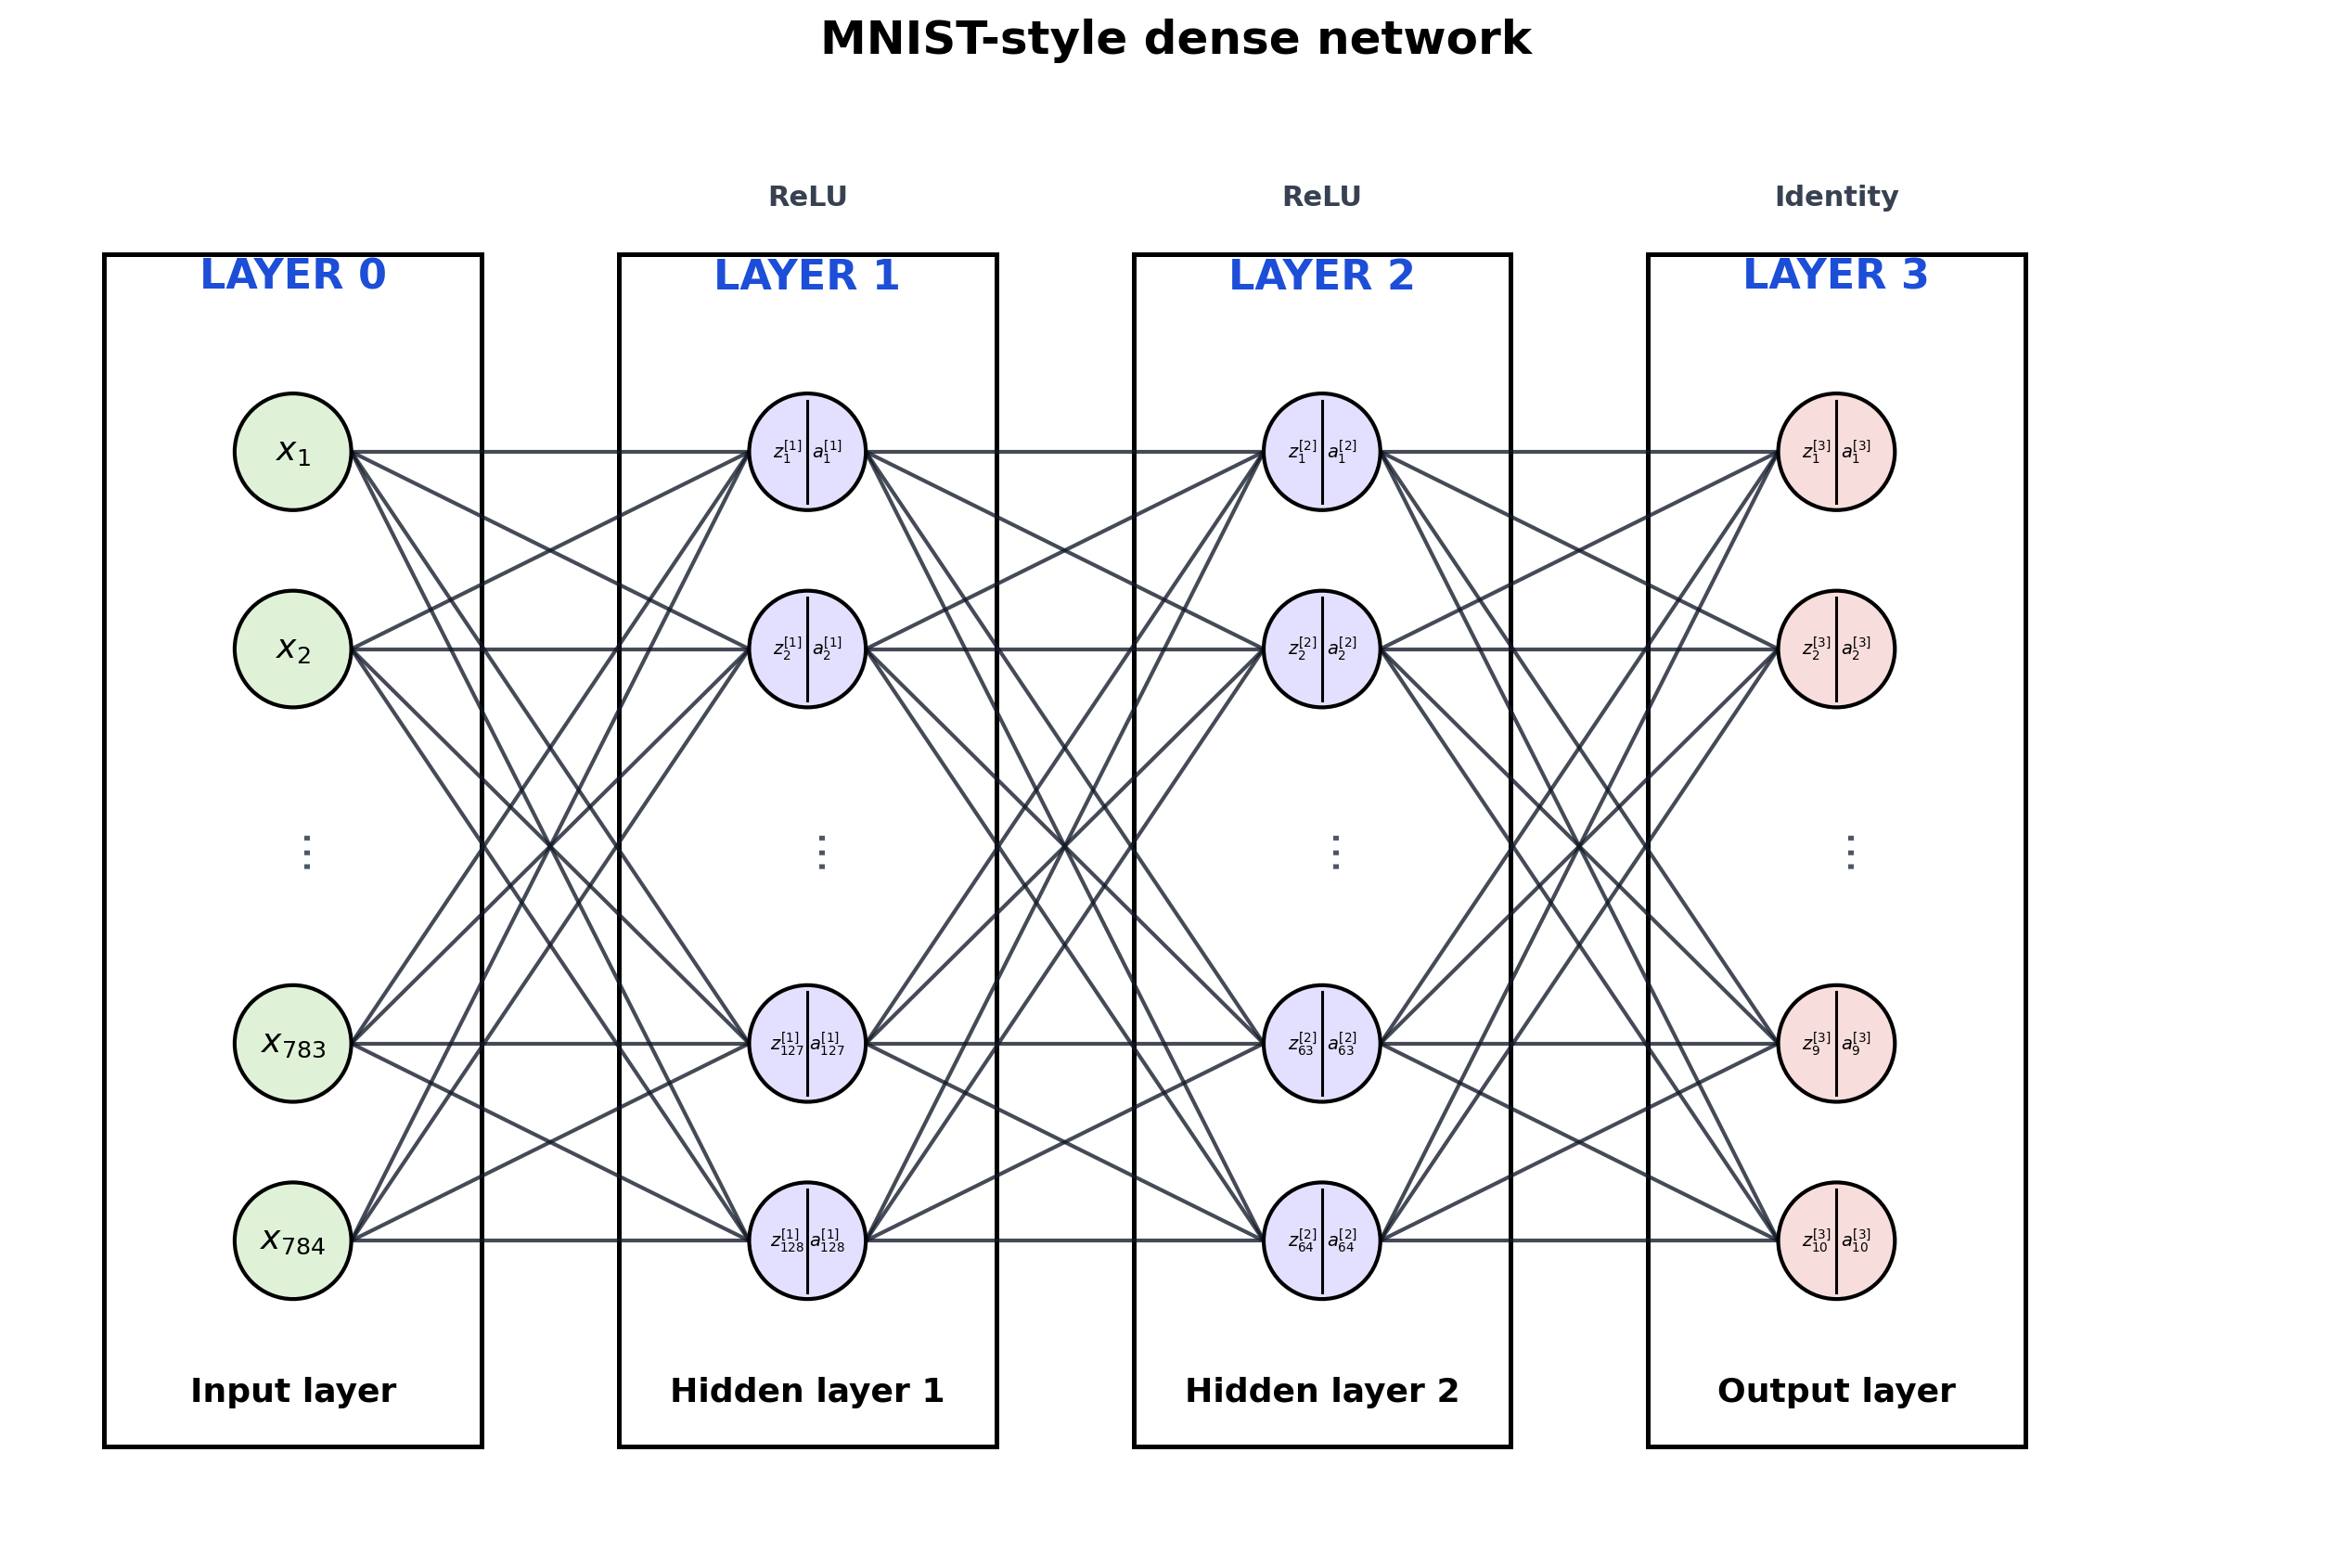

In [11]:
wide_model = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10),
)

fig, ax = visualize_fully_connected_model(
    wide_model,
    title="MNIST-style dense network",
    max_neurons_per_layer=5,
)
plt.show()


## 5. Save a Diagram

Reuse the figure in slides or notes by saving PNG and SVG.


In [12]:
output_dir = repo_root / "outputs"
png_path = output_dir / "fc_visualizer_demo.png"
svg_path = output_dir / "fc_visualizer_demo.svg"

fig, ax = visualize_fully_connected_model(
    small_model,
    input_labels=[r"$x_1$", r"$x_2$"],
    input_vector=x_example,
    title="Saved demo network",
    show_edge_weights=True,
    show_biases=True,
    show_values=True,
    show_matrix_details=True,
)
save_figure(fig, png_path=png_path, svg_path=svg_path)

print(f"Saved PNG: {png_path}")
print(f"Saved SVG: {svg_path}")


Saved PNG: /Users/nipun/git/principles-ai-teaching/outputs/fc_visualizer_demo.png
Saved SVG: /Users/nipun/git/principles-ai-teaching/outputs/fc_visualizer_demo.svg


## Notes

The visualizer traces the forward graph and looks for:

- `nn.Linear`
- activations such as `ReLU`, `Tanh`, `Sigmoid`, `Softmax`
- simple reshaping or flattening operations

Small-network extras:

- `input_vector=...` computes and annotates forward-pass values
- `show_edge_weights=True` writes each scalar weight on its edge
- `show_biases=True` shows each bias near its neuron
- `show_matrix_details=True` adds a side panel with `W`, `b`, `z`, and `a`

If the model contains convolution, skip connections, attention, concatenation, or branching, the visualizer will reject it on purpose.
